# E-Commerce Sales Data — Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
data = pd.read_csv("blinkit_data.csv")

## Data -

In [3]:
data

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   str    
 1   Item Identifier            8523 non-null   str    
 2   Item Type                  8523 non-null   str    
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   str    
 5   Outlet Location Type       8523 non-null   str    
 6   Outlet Size                8523 non-null   str    
 7   Outlet Type                8523 non-null   str    
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [5]:
data.describe()

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2010.831867,0.066132,12.857645,140.992782,3.965857
std,8.371760,0.051598,4.643456,62.275067,0.605651
min,1998.000000,0.000000,4.555000,31.290000,1.000000
25%,2000.000000,0.026989,8.773750,93.826500,4.000000
50%,2012.000000,0.053931,12.600000,143.012800,4.000000
75%,2017.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


In [6]:
data.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

In [7]:
data["Item Fat Content"].value_counts()

Item Fat Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

## Missing Values & Inconsistent Categories

`Item Weight` has missing values, and `Item Fat Content` has inconsistent labels (`Low Fat` / `low fat` / `LF` and `Regular` / `reg`) that need to be standardized before analysis.

In [8]:
data["Item Weight"] = data.groupby("Item Identifier")["Item Weight"].transform(
    lambda s: s.fillna(s.median())
)
data["Item Weight"] = data["Item Weight"].fillna(data["Item Weight"].median())
data["Item Weight"].isna().sum()

np.int64(0)

In [9]:
data.isnull().sum()

Item Fat Content             0
Item Identifier              0
Item Type                    0
Outlet Establishment Year    0
Outlet Identifier            0
Outlet Location Type         0
Outlet Size                  0
Outlet Type                  0
Item Visibility              0
Item Weight                  0
Sales                        0
Rating                       0
dtype: int64

In [10]:
fat_map = {
    "low fat": "Low Fat",
    "LF": "Low Fat",
    "reg": "Regular",
    "Regular": "Regular",
    "Low Fat": "Low Fat",
}
data["Item Fat Content"] = data["Item Fat Content"].map(fat_map)
data["Item Fat Content"].value_counts()

Item Fat Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

## Univariate Analysis — Numeric Features

In [11]:
num_cols = ["Item Weight", "Item Visibility", "Sales", "Rating"]
data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Item Weight,8523.0,12.875314,4.645010,4.555,8.785000,12.650000,16.850000,21.350000
Item Visibility,8523.0,0.066132,0.051598,0.000,0.026989,0.053931,0.094585,0.328391
Sales,8523.0,140.992782,62.275067,31.290,93.826500,143.012800,185.643700,266.888400
Rating,8523.0,3.965857,0.605651,1.000,4.000000,4.000000,4.200000,5.000000


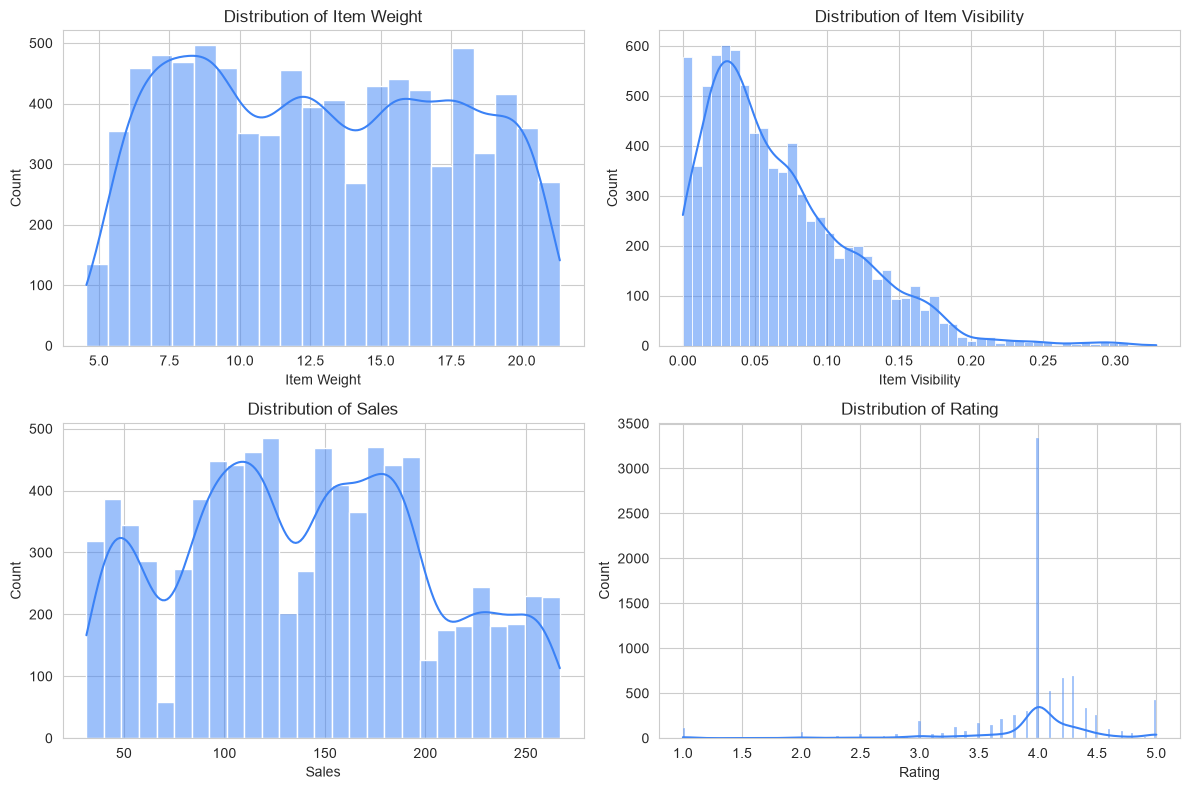

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(data[col], kde=True, ax=ax, color="#3b82f6")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

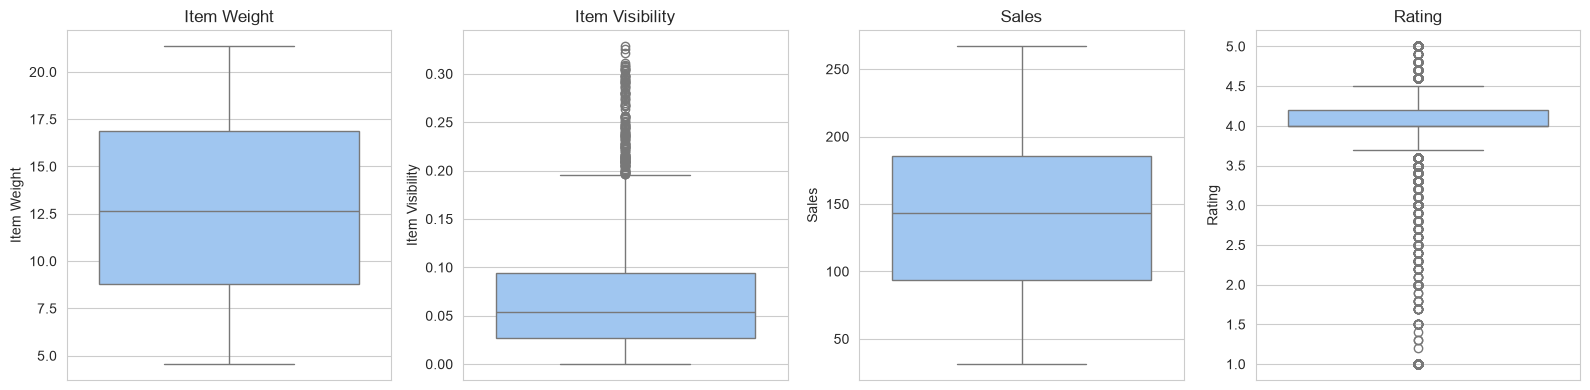

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=data[col], ax=ax, color="#93c5fd")
    ax.set_title(col)
plt.tight_layout()
plt.show()

`Sales` is right-skewed with no extreme outliers. `Item Visibility` is also right-skewed and has a floor near zero. `Rating` is concentrated between 4 and 5.

## Univariate Analysis — Categorical Features

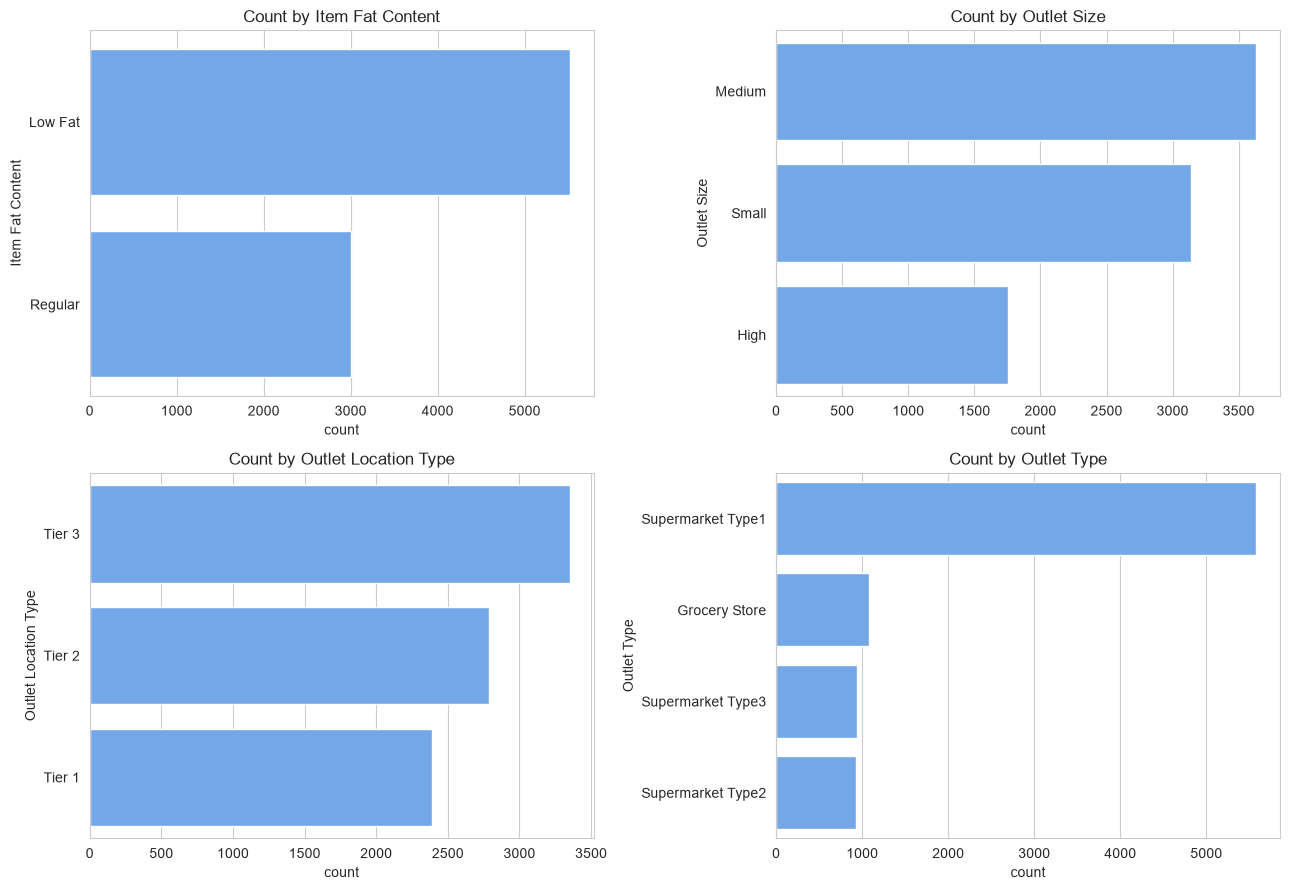

In [14]:
cat_cols = ["Item Fat Content", "Outlet Size", "Outlet Location Type", "Outlet Type"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    order = data[col].value_counts().index
    sns.countplot(y=data[col], order=order, ax=ax, color="#60a5fa")
    ax.set_title(f"Count by {col}")
plt.tight_layout()
plt.show()

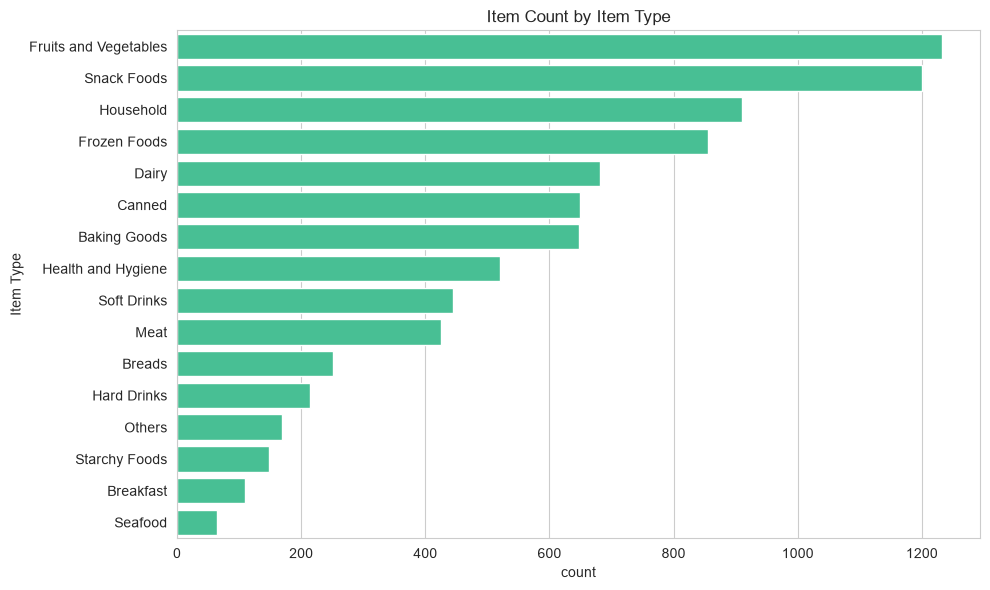

In [15]:
plt.figure(figsize=(10, 6))
order = data["Item Type"].value_counts().index
sns.countplot(y=data["Item Type"], order=order, color="#34d399")
plt.title("Item Count by Item Type")
plt.tight_layout()
plt.show()


## Sales Analysis by Outlet Attributes

In [16]:
outlet_sales = data.groupby("Outlet Type")["Sales"].agg(["mean", "sum", "count"]).sort_values("sum", ascending=False)
outlet_sales

,mean,sum,count
Outlet Type,,,
Supermarket Type1,141.213894,787549.8868,5577
Grocery Store,140.294688,151939.1470,1083
Supermarket Type2,141.678634,131477.7724,928
Supermarket Type3,139.801791,130714.6746,935


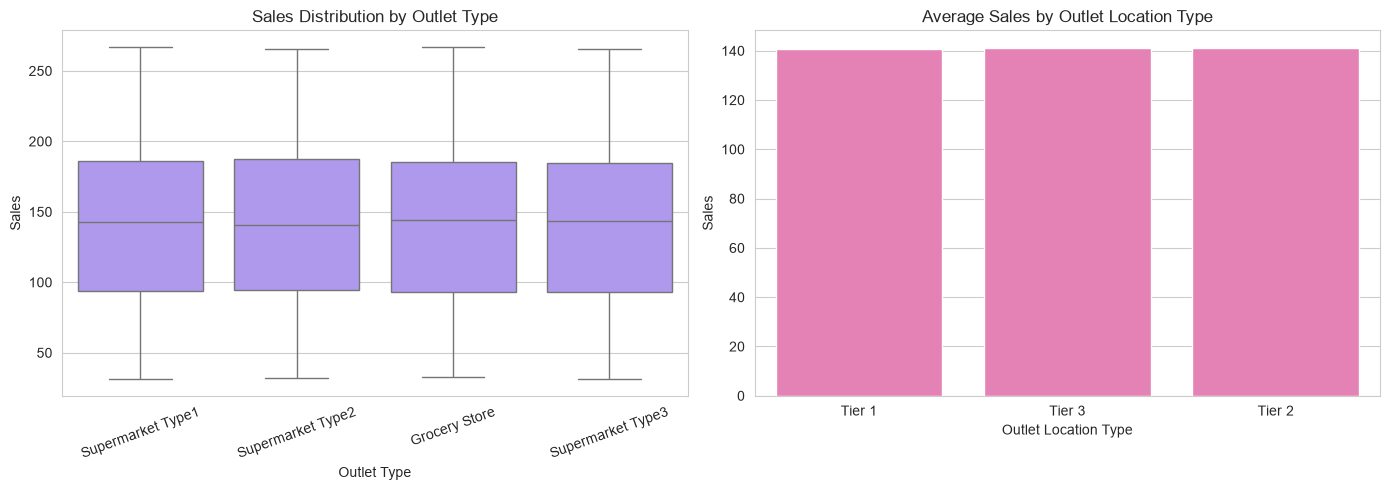

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=data, x="Outlet Type", y="Sales", ax=axes[0], color="#a78bfa")
axes[0].set_title("Sales Distribution by Outlet Type")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=data, x="Outlet Location Type", y="Sales", estimator=np.mean,
            errorbar=None, ax=axes[1], color="#f472b6")
axes[1].set_title("Average Sales by Outlet Location Type")
plt.tight_layout()
plt.show()

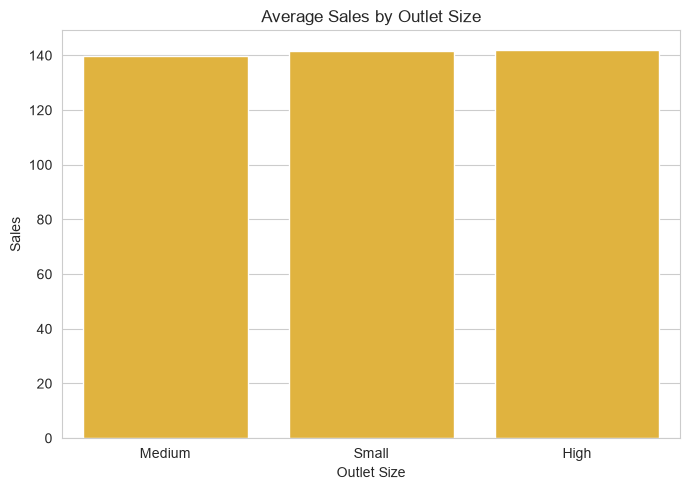

In [18]:
plt.figure(figsize=(7, 5))
sns.barplot(data=data, x="Outlet Size", y="Sales", estimator=np.mean, errorbar=None, color="#fbbf24")
plt.title("Average Sales by Outlet Size")
plt.tight_layout()
plt.show()

**Supermarket Type3** outlets generate the highest average sales, while **Grocery Stores** lag well behind the supermarket formats. This is consistent with grocery stores stocking a narrower assortment.

## Sales Analysis by Item Attributes

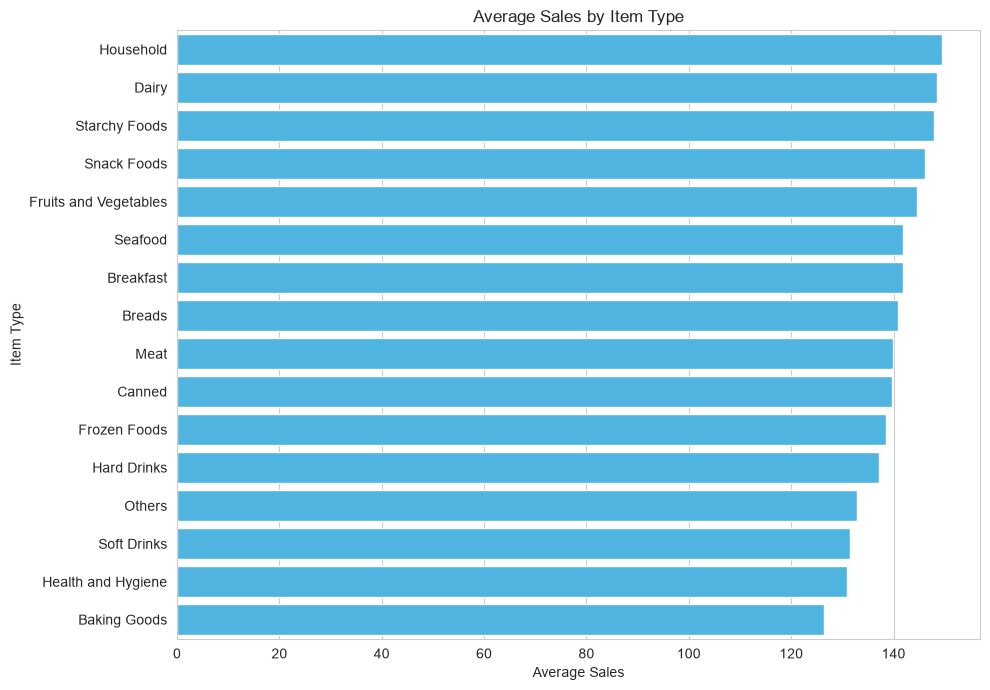

In [19]:
item_sales = data.groupby("Item Type")["Sales"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 7))
sns.barplot(x=item_sales.values, y=item_sales.index, color="#38bdf8")
plt.xlabel("Average Sales")
plt.title("Average Sales by Item Type")
plt.tight_layout()
plt.show()

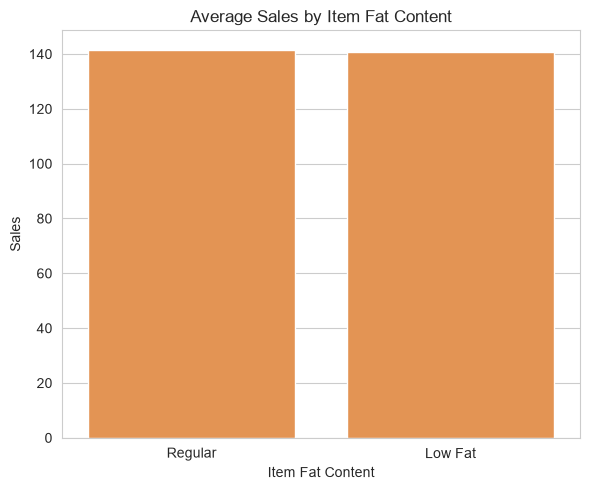

In [20]:
plt.figure(figsize=(6, 5))
sns.barplot(data=data, x="Item Fat Content", y="Sales", estimator=np.mean, errorbar=None, color="#fb923c")
plt.title("Average Sales by Item Fat Content")
plt.tight_layout()
plt.show()

## Relationships Between Numeric Features

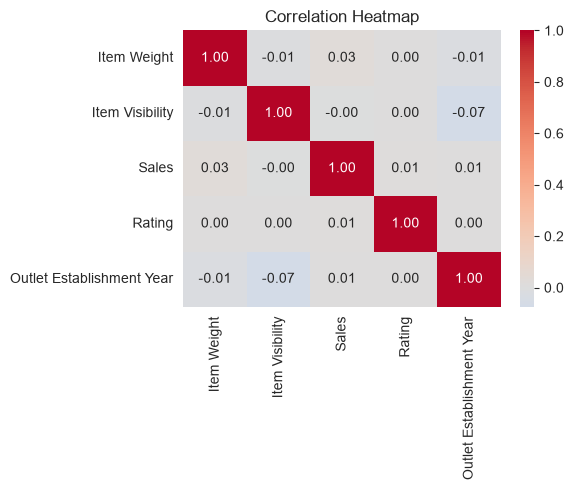

In [21]:
plt.figure(figsize=(6, 5))
corr = data[num_cols + ["Outlet Establishment Year"]].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

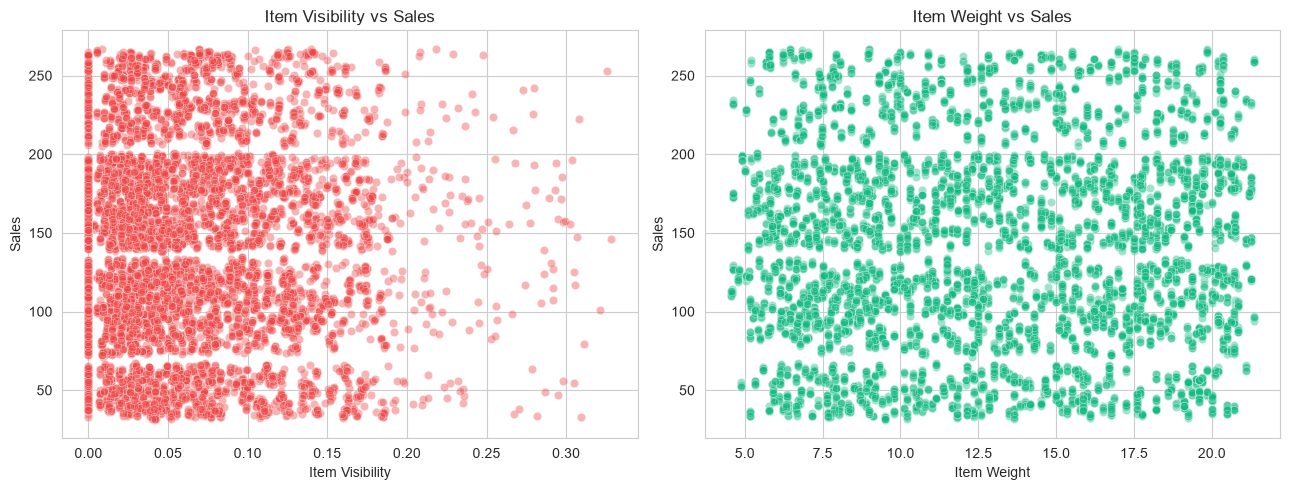

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=data, x="Item Visibility", y="Sales", alpha=0.4, ax=axes[0], color="#ef4444")
axes[0].set_title("Item Visibility vs Sales")

sns.scatterplot(data=data, x="Item Weight", y="Sales", alpha=0.4, ax=axes[1], color="#10b981")
axes[1].set_title("Item Weight vs Sales")
plt.tight_layout()
plt.show()

 —  item weight and visibility alone don't strongly predict sales, suggesting outlet-level and item-type factors matter more.

## Sales Trend by Outlet Establishment Year

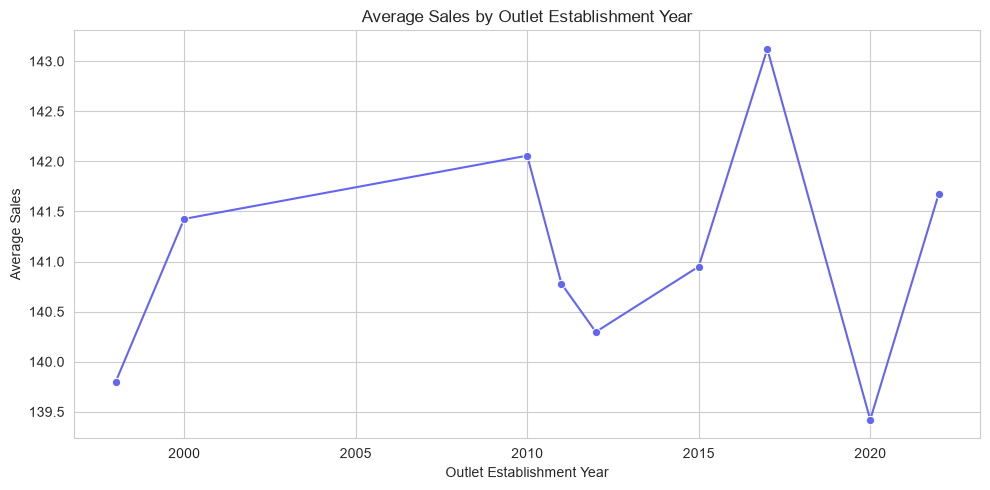

In [23]:
year_sales = data.groupby("Outlet Establishment Year")["Sales"].mean().sort_index()
plt.figure(figsize=(10, 5))
sns.lineplot(x=year_sales.index, y=year_sales.values, marker="o", color="#6366f1")
plt.title("Average Sales by Outlet Establishment Year")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

## Rating Analysis

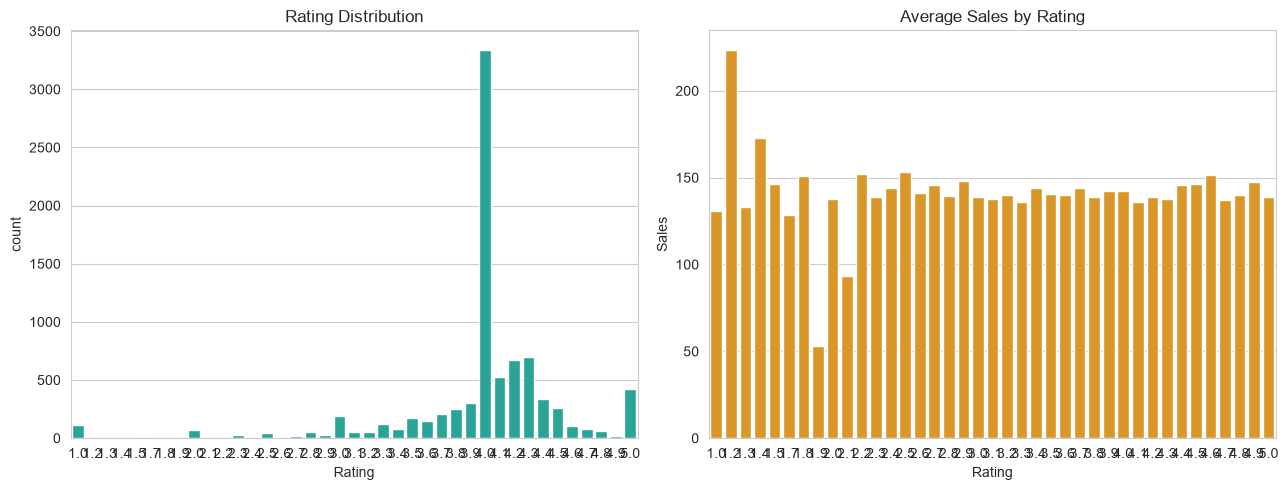

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(x=data["Rating"], ax=axes[0], color="#14b8a6")
axes[0].set_title("Rating Distribution")

sns.barplot(data=data, x="Rating", y="Sales", estimator=np.mean, errorbar=None, ax=axes[1], color="#f59e0b")
axes[1].set_title("Average Sales by Rating")
plt.tight_layout()
plt.show()

## Key Takeaways

- **Data quality**: `Item Fat Content` had 5 inconsistent labels, consolidated into `Low Fat` / `Regular`; ~17% of `Item Weight` values were missing and were imputed using per-item medians.
- **Sales distribution**: right-skewed, ranging roughly \$31 to \$267, with no extreme outliers.
- **Outlet Type** is the strongest driver of sales among the categorical features — Supermarket Type3 outperforms Grocery Stores by a wide margin.
- **Item Visibility** and **Item Weight** show only weak correlation with `Sales`, so single-variable numeric relationships don't explain sales well on their own.
- **Rating** is concentrated in the 4–5 range across the dataset and doesn't vary much with `Sales`, suggesting it may be a static/assigned field rather than a customer-driven metric.